In [1]:
# ── Cell 1 : Setup & Imports ──────────
import json
import pickle
import pathlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

project_root = next(
    p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
    if (p / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src import marginal_comparison as mc

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 4)
print("Imports successful!")

Imports successful!


In [2]:
# ── Cell 2 : Locate Sibling Sampler Runs ──────────
# This notebook sits in a <chains>/<k>_comp/ folder and compares the NUTS, HMC and
# bayesm runs that live beside it: <sampler>/<run>/results/posterior_raw.pkl.

def _resolve_dir():
    nb = globals().get("__vsc_ipynb_file__")
    return pathlib.Path(nb).resolve().parent if nb else pathlib.Path.cwd()

XCOMP_DIR = _resolve_dir()
hits = sorted(XCOMP_DIR.glob("*/*/results/posterior_raw.pkl"))
if not hits:
    raise FileNotFoundError(
        f"No <sampler>/<run>/results/posterior_raw.pkl under:\n  {XCOMP_DIR}\n"
        f"This notebook must sit in a <chains>/<k>_comp/ folder. In VS Code set\n"
        f'  "jupyter.notebookFileRoot": "${{fileDirname}}"  and restart the kernel.'
    )

runs = {}
for h in hits:
    sampler = h.parents[2].name          # NUTS / HMC / bayesm
    runs.setdefault(sampler, h.parent)   # first run's results dir per sampler

meta = json.load(open(next(iter(runs.values())) / "meta.json"))
SCENARIO = meta["scenario"]
K_MODEL  = int(meta["k_model"])
K_TRUE   = int(meta["k_true"])
CHAINS   = int(meta["chains"])

print(f"x_comp folder : {XCOMP_DIR}")
print(f"scenario={SCENARIO}  K_MODEL={K_MODEL}  K_TRUE={K_TRUE}")
print(f"samplers found: {list(runs)}")

models = [mc.load_sampler(rd, name) for name, rd in runs.items()]
for m in models:
    print(f"  {m['name']:<8} mu {m['mu'].shape}")

x_comp folder : C:\Users\ThinkPad\Desktop\Repositories\HierarchicalBayesianMultinomialLogit\hbmnl_mixture_experiments\2_chains\5_comp
scenario=5comp_equal  K_MODEL=5  K_TRUE=5
samplers found: ['bayesm', 'HMC', 'NUTS', 'replication']


  bayesm   mu (2, 10000, 5, 4)
  HMC      mu (2, 10000, 5, 4)
  NUTS     mu (2, 10000, 5, 4)
  replication mu (2, 10000, 5, 4)


In [3]:
# ── Cell 3 : Ground Truth & Grids ──────────
# Grids are anchored to the FITTED models' live-component support (union over
# samplers); the True DGP is an overlay only, never used to set the bounds.
raw = json.load(open(project_root / "data" / "simulated" / "mixture" / f"{SCENARIO}.json"))
P = int(raw["n_params"])
param_names = raw.get("param_names") or [f"Param_{i}" for i in range(P)]
true_model = mc.true_dgp_model(raw)

grids = mc.build_grids(models, K_true=K_TRUE, n_grid=1000, n_sigma=4)
print("Grid extents (fitted-support, live components):")
for j, pj in enumerate(param_names):
    print(f"  {pj:<10} [{grids[j][0]:+.2f}, {grids[j][-1]:+.2f}]")

Grid extents (fitted-support, live components):
  Alt1       [-38.52, +40.82]
  Alt2       [-29.98, +32.54]
  Alt3       [-27.95, +24.85]
  Price      [-20.96, +18.01]


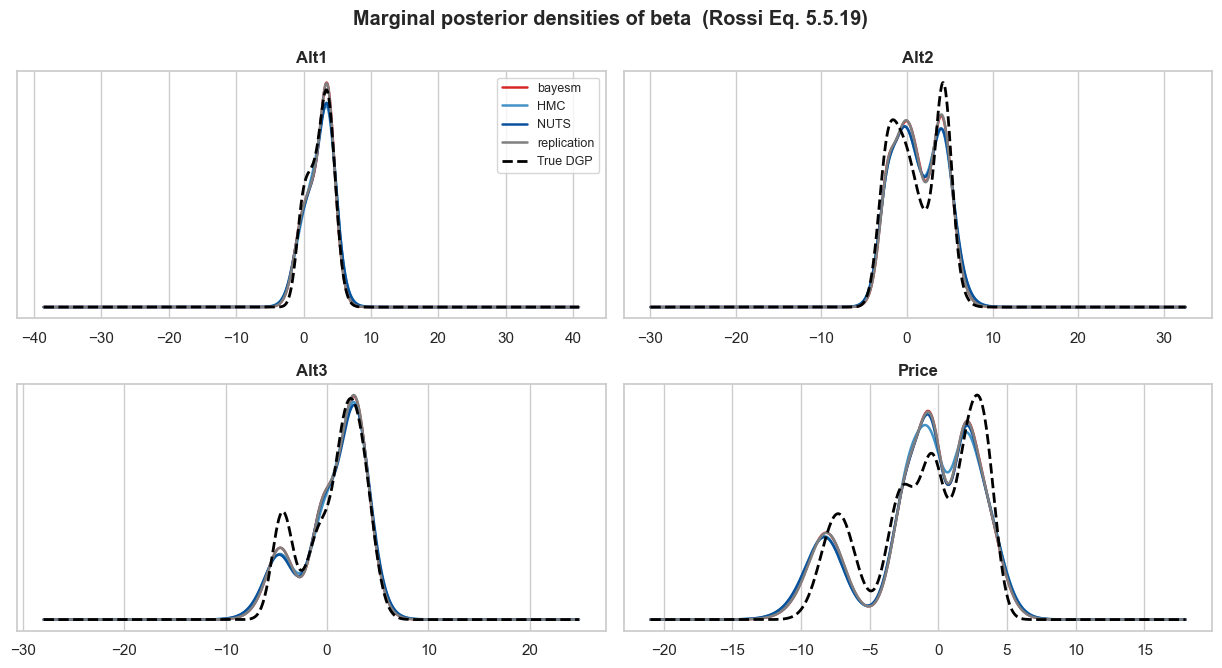

In [4]:
# ── Cell 4 : Marginal Densities (Rossi Eq. 5.5.19) ──────────
dens      = {m["name"]: mc.marginal_density(m, grids) for m in models}
dens_true = mc.marginal_density(true_model, grids)
# True DGP = black (dashed reference), bayesm = red, Liesel samplers = distinct
# shades of blue (ColorBrewer Blues: dark -> light).
colors = {"NUTS": "#08519c", "HMC": "#4292c6", "iwls": "#9ecae1", "bayesm": "#d62728"}
TRUE_COLOR = "#000000"

ncols = min(P, 2)
nrows = int(np.ceil(P / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6.2, nrows * 3.4), squeeze=False)
ax = axes.ravel()
for j, pj in enumerate(param_names):
    for name, d in dens.items():
        ax[j].plot(grids[j], d[j], lw=1.8, label=name, color=colors.get(name, "#7f7f7f"))
    ax[j].plot(grids[j], dens_true[j], lw=2.0, ls="--", color=TRUE_COLOR, label="True DGP")
    ax[j].set_title(pj, fontweight="bold")
    ax[j].set_yticks([])
for j in range(P, len(ax)):
    ax[j].set_visible(False)
ax[0].legend(fontsize=9)
fig.suptitle("Marginal posterior densities of beta  (Rossi Eq. 5.5.19)", fontweight="bold")
fig.tight_layout()
plt.show()

In [5]:
# ── Cell 5 : Density Distances vs True DGP ──────────
# Every sampler's marginal is compared ONLY to the True DGP marginal (never to
# another sampler). Metrics: Hellinger (primary), KL(model||true), Jensen-Shannon,
# total-variation, Wasserstein-1. All label-invariant - relabeling/ECR would not
# change them.
display(mc.distance_table(models, true_model, grids, param_names))

Hellinger       KL      JSD      TVD  Wasserstein1
sampler     param                                                    
bayesm      Alt1     0.06848  0.02593  0.00442  0.04200       0.10896
            Alt2     0.07071  0.02071  0.00497  0.08559       0.23721
            Alt3     0.09106  0.05169  0.00768  0.06425       0.20297
            Price    0.14324  0.10232  0.01961  0.14132       0.38727
HMC         Alt1     0.09752  0.09462  0.00865  0.06271       0.19301
            Alt2     0.08607  0.04909  0.00718  0.09311       0.24799
            Alt3     0.11022  0.09835  0.01096  0.06824       0.25992
            Price    0.15954  0.14212  0.02394  0.15159       0.40940
NUTS        Alt1     0.09250  0.05213  0.00796  0.06441       0.19471
            Alt2     0.08371  0.03258  0.00687  0.09207       0.24591
            Alt3     0.11424  0.09016  0.01188  0.07996       0.27013
            Price    0.15774  0.13515  0.02341  0.14770       0.41170
replication Alt1     0.06775  0.02537  0.00433  0.04031       0.10477
            Alt2     0.07001  0.02028  0.00488  0.08467       0.23542
            Alt3     0.09031  0.04992  0.00756  0.06358       0.20374
            Price    0.14240  0.10104  0.01938  0.14129       0.38634

In [6]:
# ── Cell 6 : Mixture Moments (Rossi Eq. 5.5.2) & Weights ──────────
allm = models + [true_model]
mean_tbl = pd.DataFrame({m["name"]: mc.mixture_moments(m)[0] for m in allm}, index=param_names)
var_tbl  = pd.DataFrame({m["name"]: np.diag(mc.mixture_moments(m)[1]) for m in allm}, index=param_names)
print("E[theta]  (overall mixture mean):")
display(mean_tbl.round(3))
print("diag Var[theta]  (overall mixture variance):")
display(var_tbl.round(3))

E[theta]  (overall mixture mean):


,bayesm,HMC,NUTS,replication,True DGP
Alt1,2.346,2.402,2.396,2.346,2.388
Alt2,1.318,1.333,1.346,1.318,1.142
Alt3,0.634,0.644,0.649,0.638,0.560
Price,-1.127,-1.139,-1.149,-1.125,-1.000


diag Var[theta]  (overall mixture variance):


,bayesm,HMC,NUTS,replication,True DGP
Alt1,4.162,5.113000,4.666000,4.153,3.603
Alt2,7.811,8.500000,8.374000,7.802,8.496
Alt3,10.200,10.890000,10.858000,10.158,9.511
Price,16.632,17.403999,17.311001,16.586,15.138


In [7]:
# ── Cell 7 : Invariant Convergence - Marginal Density Series ──────────
# ESS / R-hat (arviz rank-normalised split-R-hat) of the label-invariant per-draw
# marginal density, over the high-density region of each parameter.
if CHAINS == 1:
    print("NOTE: single chain -> R-hat is SPLIT-R-hat (the one chain is halved); a")
    print("      WITHIN-chain check only (Vehtari et al. 2021; Stan; BDA3 sec. 11.4).")
    print("      It cannot detect multimodality a lone chain never explored - the")
    print("      between-chain R-hat comes from the 2-chain runs.\n")
for m in models:
    print(f"--- {m['name']} ---")
    display(mc.density_series_diagnostics(m, grids, param_names, n_eval=40).round(3))

--- bayesm ---


,n_pts,min_ESS,mean_ESS,max_Rhat,mean_Rhat
param,,,,,
Alt1,5,669.876,1778.896,1.003,1.001
Alt2,9,717.515,1267.242,1.002,1.001
Alt3,12,477.074,1319.454,1.003,1.001
Price,20,245.510,1593.562,1.013,1.004


--- HMC ---


,n_pts,min_ESS,mean_ESS,max_Rhat,mean_Rhat
param,,,,,
Alt1,7,11.177,115.373,1.122,1.068
Alt2,9,7.004,222.097,1.200,1.051
Alt3,13,4.688,180.885,1.337,1.070
Price,21,4.469,208.911,1.360,1.074


--- NUTS ---


,n_pts,min_ESS,mean_ESS,max_Rhat,mean_Rhat
param,,,,,
Alt1,7,1459.728,3225.356,1.004,1.002
Alt2,9,1513.301,2421.704,1.002,1.001
Alt3,13,1303.287,2628.530,1.001,1.001
Price,21,903.650,3174.240,1.002,1.001


--- replication ---


,n_pts,min_ESS,mean_ESS,max_Rhat,mean_Rhat
param,,,,,
Alt1,5,642.464,1850.614,1.007,1.003
Alt2,9,625.422,1310.508,1.008,1.002
Alt3,12,544.869,1369.807,1.005,1.002
Price,19,219.306,1730.517,1.011,1.003


In [8]:
# ── Cell 8 : Invariant Convergence - Moment Series & Notes ──────────
for m in models:
    print(f"--- {m['name']} ---")
    display(mc.moment_series_diagnostics(m, param_names).round(4))

print("\nNotes:")
print(" - Every quantity here (marginal density Eq. 5.5.19, moments Eq. 5.5.2) is")
print("   LABEL-INVARIANT: a per-draw permutation of components leaves it unchanged,")
print("   so relabeling/ECR is unnecessary and would give identical results.")
print(" - The grid is anchored to the fitted models' live-component support; the True")
print("   DGP is an overlay only, never used to set the bounds.")
print(" - R-hat/ESS use arviz rank-normalised split-R-hat on the real (chains,draws)")
print("   series (Vehtari et al. 2021). For 1-chain runs the single chain is split")
print("   into halves (Stan; BDA3 sec. 11.4) - a within-chain check only. bayesm's")
print("   seed-based chains are not over-dispersed, so its R-hat is a weaker test")
print("   than NUTS/HMC (per CLAUDE.md).")

--- bayesm ---


ESS    Rhat
param moment                   
Alt1  Mean    1456.5281  1.0013
      Var     1291.8730  1.0005
Alt2  Mean    3141.4126  1.0003
      Var      953.2706  1.0014
Alt3  Mean    1903.3343  1.0000
      Var      574.8830  1.0010
Price Mean    1767.4349  1.0017
      Var      399.4535  1.0080

--- HMC ---


ESS    Rhat
param moment                   
Alt1  Mean     460.8056  1.0039
      Var       54.8493  1.0354
Alt2  Mean    1058.0159  1.0037
      Var       57.1917  1.0340
Alt3  Mean     519.6881  1.0033
      Var      219.7666  1.0069
Price Mean     914.6139  1.0014
      Var      265.1288  1.0028

--- NUTS ---


ESS    Rhat
param moment                   
Alt1  Mean    3101.2086  1.0014
      Var     2093.7709  1.0016
Alt2  Mean    5801.7934  1.0002
      Var     1856.0511  1.0015
Alt3  Mean    4162.7078  1.0001
      Var     2079.5370  1.0011
Price Mean    5569.7530  1.0001
      Var     1416.7263  1.0016

--- replication ---


ESS    Rhat
param moment                   
Alt1  Mean    1682.9013  1.0035
      Var     1285.1650  1.0021
Alt2  Mean    3010.5850  1.0002
      Var     1159.2274  1.0064
Alt3  Mean    1912.4234  1.0002
      Var      763.5695  1.0026
Price Mean    2299.5674  1.0013
      Var      406.2647  1.0086


Notes:
 - Every quantity here (marginal density Eq. 5.5.19, moments Eq. 5.5.2) is
   LABEL-INVARIANT: a per-draw permutation of components leaves it unchanged,
   so relabeling/ECR is unnecessary and would give identical results.
 - The grid is anchored to the fitted models' live-component support; the True
   DGP is an overlay only, never used to set the bounds.
 - R-hat/ESS use arviz rank-normalised split-R-hat on the real (chains,draws)
   series (Vehtari et al. 2021). For 1-chain runs the single chain is split
   into halves (Stan; BDA3 sec. 11.4) - a within-chain check only. bayesm's
   seed-based chains are not over-dispersed, so its R-hat is a weaker test
   than NUTS/HMC (per CLAUDE.md).
